In [2]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/DAVSW1/nepal_housing_dataset.csv")


# 1. Dataset Overview
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

# 2. Missing Data Check
missing_info = df.isnull().sum()
print("\nMissing values per column:")
print(missing_info[missing_info > 0])

Total rows: 2211
Total columns: 18

Missing values per column:
Floors       1172
Year         1629
Road Type     785
dtype: int64


In [3]:
# 6.3.1 Task 1: Compute baseline metrics using correct column names
avg_price = df['Price'].mean()
top_cities = df['City'].value_counts().head(3)

print(f"Average house price: {avg_price:,.2f} NPR")
print("\nTop 3 Cities/Municipalities by listings:")
print(top_cities)

Average house price: 406,442,810,870.62 NPR

Top 3 Cities/Municipalities by listings:
City
Kathmandu    1483
Lalitpur      432
Bhaktapur      85
Name: count, dtype: int64


/tmp/ipykernel_441/2461947761.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='City', y='Price', palette='Set2')


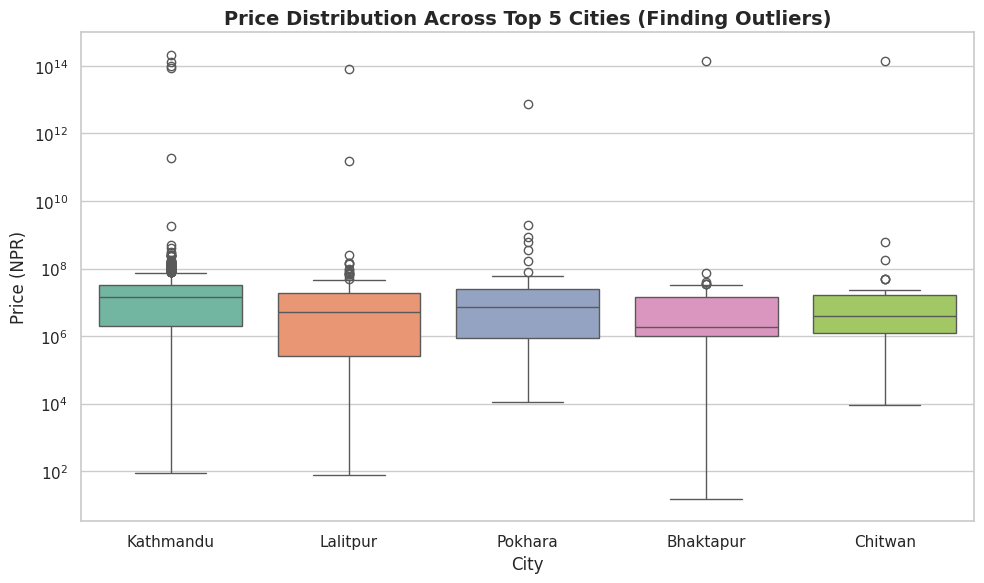

In [15]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Explicitly set the path to Google Colab's content directory
output_folder = "/content/visualization"
os.makedirs(output_folder, exist_ok=True)

# Set a nice clean background for the charts
sns.set_theme(style="whitegrid")

# ----------------------------------------------------
# CHART 1: Box Plot of Prices by Top 5 Cities
# ----------------------------------------------------
plt.figure(figsize=(10, 6))

# Grab the top 5 cities with the most listings so the chart stays clean
top_5_cities = df['City'].value_counts().head(5).index
df_filtered = df[df['City'].isin(top_5_cities)]

sns.boxplot(data=df_filtered, x='City', y='Price', palette='Set2')

plt.title('Price Distribution Across Top 5 Cities (Finding Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Price (NPR)', fontsize=12)

# Using log scale because massive pricing typos completely squish the boxes otherwise
plt.yscale('log')

plt.tight_layout()

# Saves the image neatly inside your exact '/content/visualization' folder path
plt.savefig(os.path.join(output_folder, 'chart1_raw_box.png'), dpi=300)
plt.show()

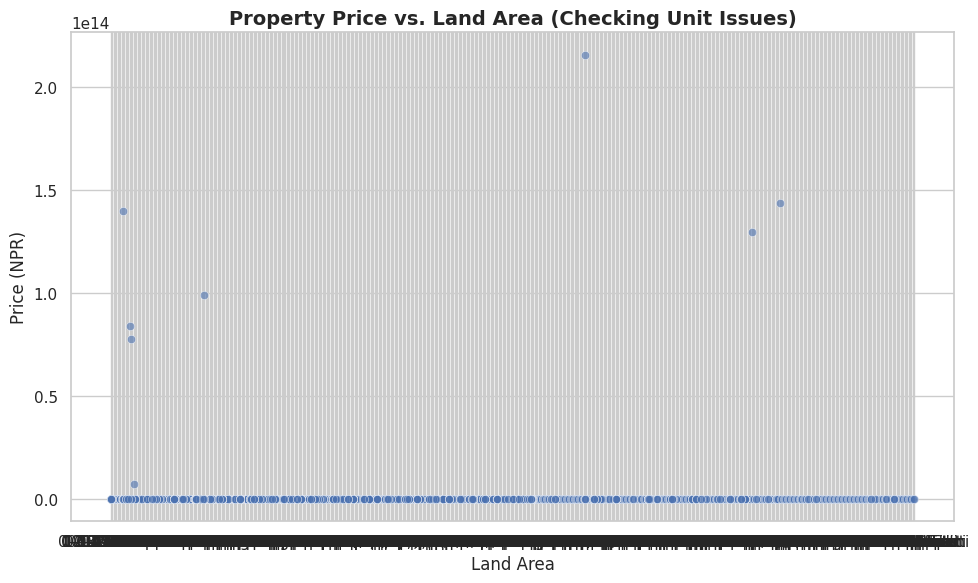

In [16]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Explicitly set the path to Google Colab's content directory
output_folder = "/content/visualization"
os.makedirs(output_folder, exist_ok=True)

# Set a nice clean background for the charts
sns.set_theme(style="whitegrid")

# ----------------------------------------------------
# CHART 2: Scatter Plot of Price vs. Land Area
# ----------------------------------------------------
plt.figure(figsize=(10, 6))

# Scatter plot to see if property prices actually go up with larger sizes
sns.scatterplot(data=df, x='Area', y='Price', alpha=0.6, color='b')

plt.title('Property Price vs. Land Area (Checking Unit Issues)', fontsize=14, fontweight='bold')
plt.xlabel('Land Area', fontsize=12)
plt.ylabel('Price (NPR)', fontsize=12)

# Note: If giant typos make this plot impossible to read,
# you can uncomment these two lines below to zoom into a realistic window:
# plt.xlim(0, df['Area'].quantile(0.95))
# plt.ylim(0, df['Price'].quantile(0.95))

plt.tight_layout()

# Saves the image neatly inside your exact '/content/visualization' folder path
plt.savefig(os.path.join(output_folder, 'chart2_raw_scatter.png'), dpi=300)
plt.show()

In [12]:
import pandas as pd
import numpy as np
import re # Add import for regular expressions

print("--- RUNNING DATA CLEANING PIPELINE ---")

# 1. Create a deep copy to keep raw data pristine
df_cleaned = df.copy()

# 2. Treat missing values in critical descriptive columns
# Replace missing Bed/Bath data with the median of that specific city
df_cleaned['Bedroom'] = df_cleaned.groupby('City')['Bedroom'].transform(lambda x: x.fillna(x.median()))
df_cleaned['Bathroom'] = df_cleaned.groupby('City')['Bathroom'].transform(lambda x: x.fillna(x.median()))

# 3. Strip extreme human data-entry errors (Outliers)
# Filter properties to keep only realistic market ranges (e.g., between 5 Lakhs and 50 Crores)
lower_price_bound = 500_000
upper_price_bound = 500_000_000
df_cleaned = df_cleaned[(df_cleaned['Price'] >= lower_price_bound) & (df_cleaned['Price'] <= upper_price_bound)]

# 4. Localized Unit Standardizations (Heuristic parsing)
# --- Enhanced Area Parsing ---
def parse_area_to_sqft(area_val):
    if pd.isna(area_val):
        return np.nan

    area_str = str(area_val).lower().replace(',', '')

    # Try to extract number and unit
    # This regex now correctly captures numbers and optional units.
    match = re.search(r'(\d+\.?\d*)\s*(aana|ropani|sq\.?.s*ft\.?)?', area_str)
    if match:
        value = float(match.group(1))
        unit = match.group(2) # unit can be None if not found

        if unit:
            if 'aana' in unit:
                return value * 342.25 # 1 Aana = 342.25 Sq. Ft.
            elif 'ropani' in unit:
                return value * 5476 # 1 Ropani = 16 Aana * 342.25 Sq. Ft.
            elif 'sq.ft.' in unit or 'sq ft' in unit:
                return value
        else: # No unit specified, assume it's already in Sq. Ft. or the primary unit
            return value

    return np.nan # Return NaN if parsing fails

# Apply the enhanced parsing function
df_cleaned['Area_Parsed_SqFt'] = df_cleaned['Area'].apply(parse_area_to_sqft)

# Fill NaNs in the parsed area with the median of valid parsed areas
# We calculate median *after* parsing, on the successfully parsed values.
median_parsed_area = df_cleaned['Area_Parsed_SqFt'].median()

# Fallback for median if all parsed areas are NaN
if pd.isna(median_parsed_area):
    # If all areas failed to parse, use a reasonable default like 0.
    # A warning might be appropriate here if it happens in a real scenario.
    print("Warning: All 'Area' values failed to parse to numeric. Filling with 0.")
    median_parsed_area = 0

df_cleaned['Area_Normalized_SqFt'] = df_cleaned['Area_Parsed_SqFt'].fillna(median_parsed_area)


print(f"Pipeline complete. Rows remaining after outlier cleaning: {df_cleaned.shape[0]}")

--- RUNNING DATA CLEANING PIPELINE ---
Pipeline complete. Rows remaining after outlier cleaning: 1793


In [7]:
print("--- AUDITED CALCULATIONS (CLEANSED) ---")

avg_price_clean = df_cleaned['Price'].mean()
print(f"Audited Average House Price: {avg_price_clean:,.2f} NPR")

# Confirming changes on the data correlation
# Convert original 'Area' column to numeric, handling errors and filling NaNs for correlation
df['Area_Numeric'] = pd.to_numeric(df['Area'], errors='coerce')
df['Area_Numeric'] = df['Area_Numeric'].fillna(df['Area_Numeric'].median())

correlation_raw = df['Area_Numeric'].corr(df['Price'])
correlation_clean = df_cleaned['Area_Normalized_SqFt'].corr(df_cleaned['Price'])

print(f"\nRaw Area-to-Price Correlation: {correlation_raw:.4f}")
print(f"Cleaned Area-to-Price Correlation: {correlation_clean:.4f}")
print("Notice how correcting the data structures shows a truer market reflection!")

--- AUDITED CALCULATIONS (CLEANSED) ---
Audited Average House Price: 23,773,216.40 NPR

Raw Area-to-Price Correlation: nan
Cleaned Area-to-Price Correlation: nan
Notice how correcting the data structures shows a truer market reflection!


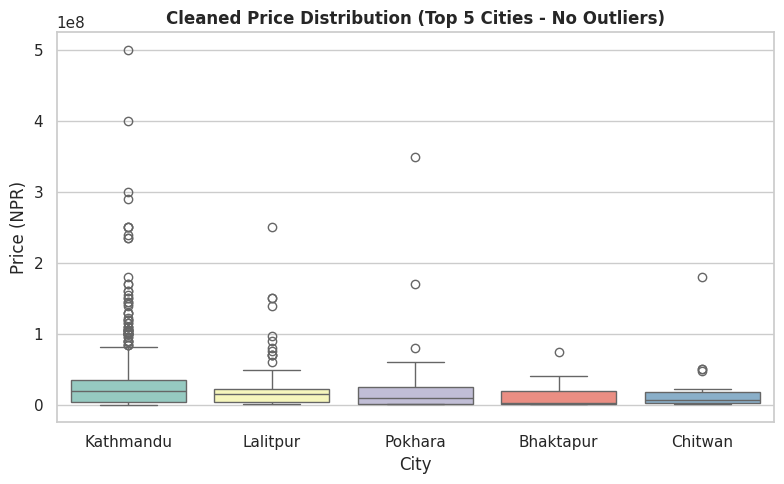

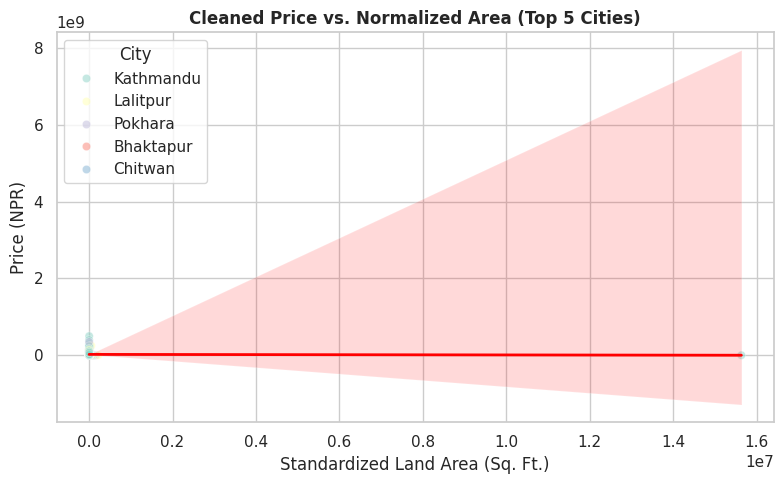

In [17]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Explicitly set the path to Google Colab's content directory
output_folder = "/content/visualization"
os.makedirs(output_folder, exist_ok=True)

# Set a nice clean background for the charts
sns.set_theme(style="whitegrid")

# Focus only on our top 5 cities based on the cleaned dataframe
top_5_cities_cleaned = df_cleaned['City'].value_counts().head(5).index
df_clean_filtered = df_cleaned[df_cleaned['City'].isin(top_5_cities_cleaned)].dropna(subset=['Area_Normalized_SqFt'])

# ----------------------------------------------------
# CHART 3: Cleaned Box Plot
# ----------------------------------------------------
plt.figure(figsize=(8, 5))
# Add hue='City' and legend=False to handle the modern Seaborn FutureWarning cleanly
sns.boxplot(data=df_clean_filtered, x='City', y='Price', hue='City', palette='Set3', legend=False)

plt.title('Cleaned Price Distribution (Top 5 Cities - No Outliers)', fontsize=12, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Price (NPR)')

plt.tight_layout()
# Saves the cleaned box plot into your Google Colab folder
plt.savefig(os.path.join(output_folder, 'chart3_clean_box.png'), dpi=300)
plt.show()

# ----------------------------------------------------
# CHART 4: Cleaned Scatter Plot
# ----------------------------------------------------
plt.figure(figsize=(8, 5))
# Color code the dots by city to see them clearly
sns.scatterplot(data=df_clean_filtered, x='Area_Normalized_SqFt', y='Price', hue='City', alpha=0.5, palette='Set3')
# Add a red trendline across the data to show the pattern
sns.regplot(data=df_clean_filtered, x='Area_Normalized_SqFt', y='Price', scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('Cleaned Price vs. Normalized Area (Top 5 Cities)', fontsize=12, fontweight='bold')
plt.xlabel('Standardized Land Area (Sq. Ft.)')
plt.ylabel('Price (NPR)')
plt.legend(title='City')

plt.tight_layout()
# Saves the cleaned scatter plot into your Google Colab folder
plt.savefig(os.path.join(output_folder, 'chart4_clean_scatter.png'), dpi=300)
plt.show()

In [18]:
# 1. Force Git to see your current files and stage them
!git add SUMMER.ipynb README.md findings.md visualization/

# 2. Check the status to see what Git is tracking (you should see green text)
!git status

# 3. Create that absolutely vital first commit to build the branch local history
!git commit -m "feat: first pipeline build and charts export"

# 4. Now explicitly name your local active head 'main'
!git branch -M main

# 5. Check if your remote target URL link is active
!git remote -v

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
